## Level 2 – Task 1: Restaurant Ratings

## Objective

Analyze the distribution of aggregate ratings, determine the most common rating range, and calculate the average number of votes received by restaurants.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("A:/PROJECTS/Cognifyz-Data-Analysis/data/processed/cleaned_dataset.csv")

df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
rating_counts = (
    df["aggregate_rating"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_counts.columns = ["Rating", "Restaurant Count"]

rating_counts.head()

,Rating,Restaurant Count
0,0.0,2148
1,1.8,1
2,1.9,2
3,2.0,7
4,2.1,15


In [4]:
print("Minimum Rating :", df["aggregate_rating"].min())
print("Maximum Rating :", df["aggregate_rating"].max())
print("Average Rating :", round(df["aggregate_rating"].mean(),2))

Minimum Rating : 0.0
Maximum Rating : 4.9
Average Rating : 2.67


In [5]:
rated_df = df[df["aggregate_rating"] > 0].copy()

bins = [0,1,2,3,4,5]

labels = [
    "0-1 Poor",
    "1-2 Fair",
    "2-3 Average",
    "3-4 Good",
    "4-5 Excellent"
]

rated_df["rating_range"] = pd.cut(
    rated_df["aggregate_rating"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

rated_df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes,rating_range
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,4-5 Excellent
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,4-5 Excellent
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,4-5 Excellent
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,4-5 Excellent
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,4-5 Excellent


In [6]:
rating_range_counts = (
    rated_df["rating_range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

rating_range_counts.columns = [
    "Rating Range",
    "Restaurant Count"
]

rating_range_counts

,Rating Range,Restaurant Count
0,0-1 Poor,0
1,1-2 Fair,10
2,2-3 Average,1891
3,3-4 Good,4388
4,4-5 Excellent,1114


In [7]:
most_common = rating_range_counts.sort_values(
    by="Restaurant Count",
    ascending=False
).iloc[0]

print(most_common)

Rating Range        3-4 Good
Restaurant Count        4388
Name: 3, dtype: object


In [8]:
average_votes = round(df["votes"].mean(),2)

print("Average Votes:", average_votes)

Average Votes: 156.91


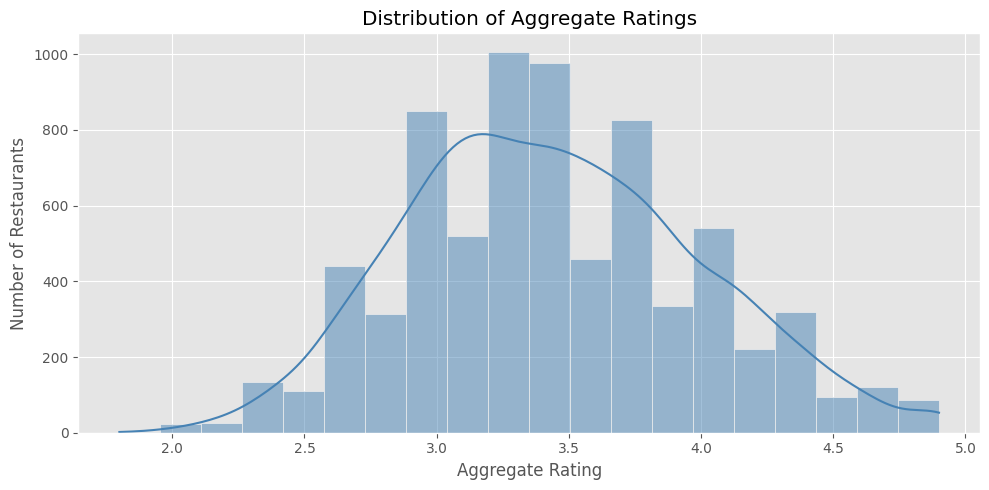

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    rated_df["aggregate_rating"],
    bins=20,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/rating_distribution.png",
    dpi=300
)

plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\2089688723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


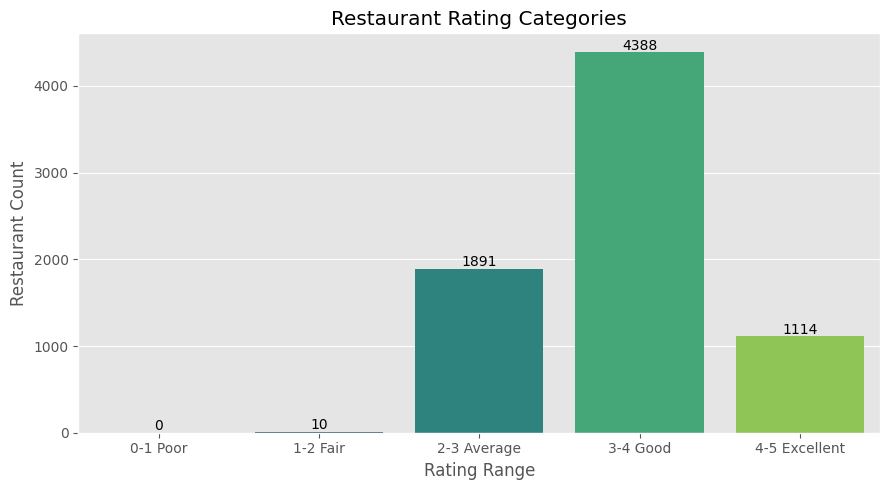

In [10]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=rating_range_counts,
    x="Rating Range",
    y="Restaurant Count",
    palette="viridis"
)

plt.title("Restaurant Rating Categories")

for index,value in enumerate(rating_range_counts["Restaurant Count"]):
    plt.text(index,value+30,str(value),ha="center")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/rating_ranges.png",
    dpi=300
)

plt.show()

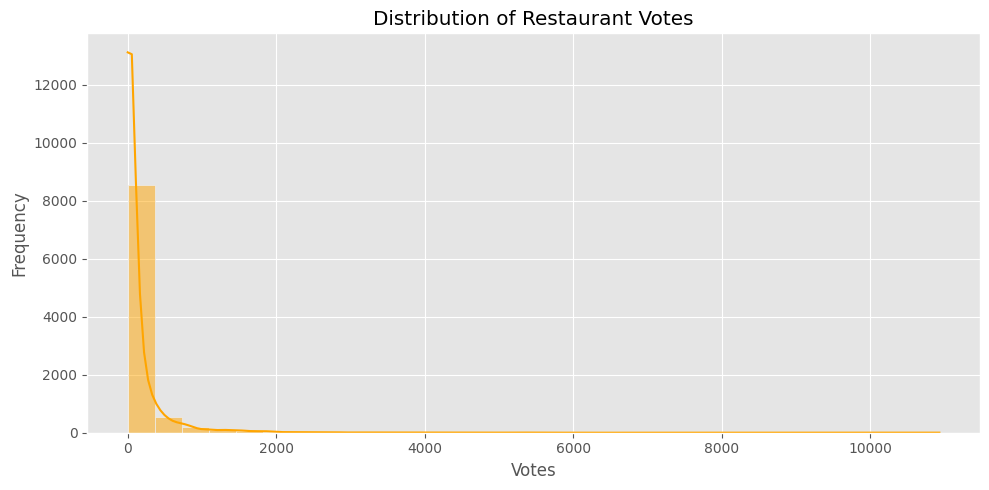

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["votes"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Distribution of Restaurant Votes")
plt.xlabel("Votes")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/votes_distribution.png",
    dpi=300
)

plt.show()

In [12]:
rating_range_counts.to_csv(
    "../outputs/restaurant_ratings.csv",
    index=False
)

In [13]:
rating_range_counts

,Rating Range,Restaurant Count
0,0-1 Poor,0
1,1-2 Fair,10
2,2-3 Average,1891
3,3-4 Good,4388
4,4-5 Excellent,1114


## Key Insights

- Most restaurants are rated between **3 and 4**, indicating generally positive customer experiences.
- Very few restaurants receive ratings below **2**, suggesting poor-performing restaurants are relatively uncommon.
- The average number of customer votes provides an indication of restaurant popularity and customer engagement.
- The rating distribution is skewed toward higher ratings, with most establishments receiving favorable reviews.

Level 2 – Task 2: Cuisine Combination

## Objective

Identify the most common combinations of cuisines in the dataset and determine whether certain cuisine combinations tend to have higher average ratings.

In [14]:
multi_cuisine_df = df[df["cuisines"].str.contains(",", na=False)].copy()

multi_cuisine_df.head()

,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,...,currency,has_table_booking,has_online_delivery,is_delivering_now,switch_to_order_menu,price_range,aggregate_rating,rating_color,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
6,6300781,Buffet 101,162,Pasay City,"Building K, SM By The Bay, Sunset Boulevard, M...","SM by the Bay, Mall of Asia Complex, Pasay City","SM by the Bay, Mall of Asia Complex, Pasay Cit...",120.979667,14.531333,"Asian, European",...,Botswana Pula(P),Yes,No,No,No,4,4.0,Green,Very Good,520


In [15]:
cuisine_combination = (
    multi_cuisine_df["cuisines"]
    .str.strip()
    .value_counts()
    .reset_index()
)

cuisine_combination.columns = [
    "Cuisine Combination",
    "Restaurant Count"
]

cuisine_combination.head(10)

,Cuisine Combination,Restaurant Count
0,"North Indian, Chinese",511
1,"North Indian, Mughlai",334
2,"North Indian, Mughlai, Chinese",197
3,"Bakery, Desserts",170
4,"Pizza, Fast Food",131
5,"Chinese, Fast Food",118
6,"Mithai, Street Food",116
7,"Bakery, Fast Food",108
8,"Chinese, North Indian",105
9,"Ice Cream, Desserts",83


In [16]:
top10_combinations = cuisine_combination.head(10)

top10_combinations

,Cuisine Combination,Restaurant Count
0,"North Indian, Chinese",511
1,"North Indian, Mughlai",334
2,"North Indian, Mughlai, Chinese",197
3,"Bakery, Desserts",170
4,"Pizza, Fast Food",131
5,"Chinese, Fast Food",118
6,"Mithai, Street Food",116
7,"Bakery, Fast Food",108
8,"Chinese, North Indian",105
9,"Ice Cream, Desserts",83


In [17]:
combination_rating = (
    multi_cuisine_df[multi_cuisine_df["aggregate_rating"] > 0]
    .groupby("cuisines")
    .agg(
        Restaurant_Count=("restaurant_name", "count"),
        Average_Rating=("aggregate_rating", "mean")
    )
    .reset_index()
)

combination_rating["Average_Rating"] = (
    combination_rating["Average_Rating"]
    .round(2)
)

combination_rating.head()

,cuisines,Restaurant_Count,Average_Rating
0,"African, Portuguese",1,4.2
1,"American, Asian, Burger",1,4.6
2,"American, Asian, European, Seafood",1,4.6
3,"American, Asian, Italian, Seafood",1,4.5
4,"American, Asian, North Indian, Mexican, South ...",1,3.3


In [18]:
popular_combinations = combination_rating[
    combination_rating["Restaurant_Count"] >= 10
]

popular_combinations = popular_combinations.sort_values(
    by="Average_Rating",
    ascending=False
)

popular_combinations.head(10)

,cuisines,Restaurant_Count,Average_Rating
22,"American, Burger",13,4.08
337,"Cafe, Continental, Italian",10,4.08
1023,"Japanese, Sushi",18,4.04
376,"Cafe, Italian",11,3.91
328,"Cafe, Continental",11,3.88
996,"Italian, Pizza",23,3.80
441,"Cafe, Tea",18,3.75
655,"Continental, North Indian",12,3.71
302,"Cafe, Bakery",13,3.70
1470,"Pizza, Italian",19,3.67


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\1495883456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


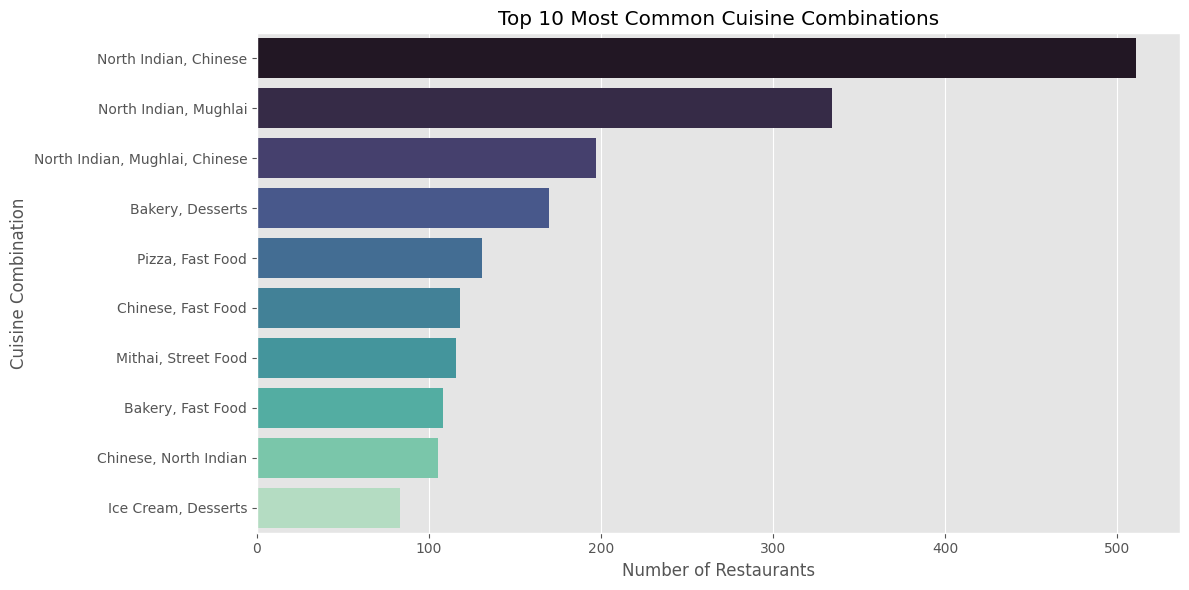

In [19]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_combinations,
    x="Restaurant Count",
    y="Cuisine Combination",
    palette="mako"
)

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/top_cuisine_combinations.png",
    dpi=300
)

plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\2999366306.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


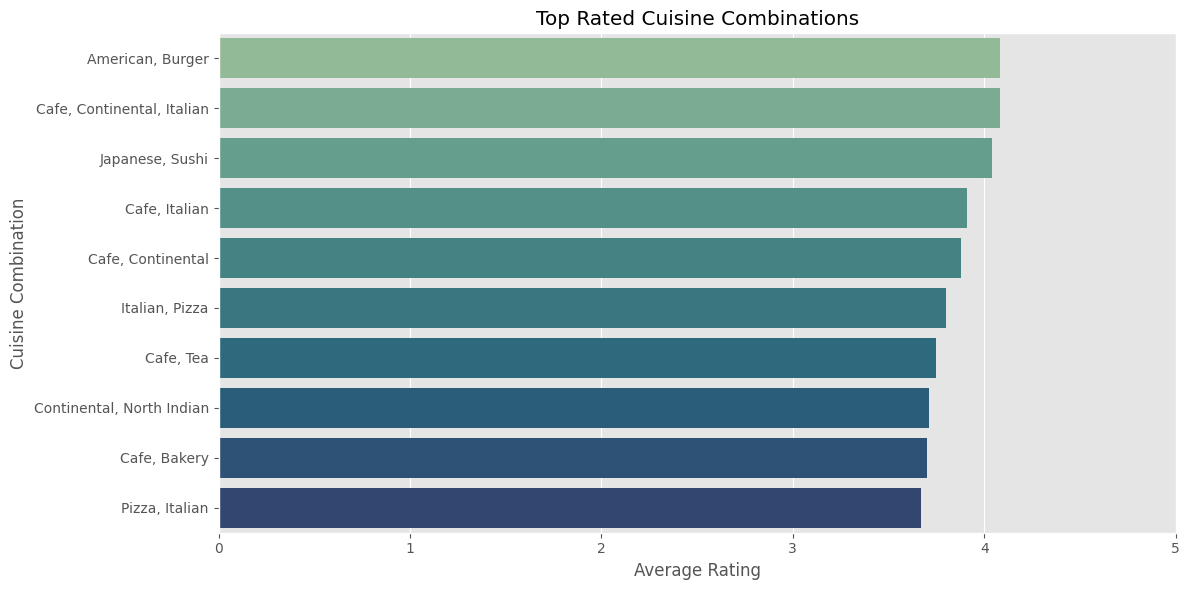

In [20]:
top_rated = popular_combinations.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated,
    x="Average_Rating",
    y="cuisines",
    palette="crest"
)

plt.title("Top Rated Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

plt.xlim(0,5)

plt.tight_layout()

plt.savefig(
    "../visuals/level2/top_rated_cuisine_combinations.png",
    dpi=300
)

plt.show()

In [21]:
top10_combinations

,Cuisine Combination,Restaurant Count
0,"North Indian, Chinese",511
1,"North Indian, Mughlai",334
2,"North Indian, Mughlai, Chinese",197
3,"Bakery, Desserts",170
4,"Pizza, Fast Food",131
5,"Chinese, Fast Food",118
6,"Mithai, Street Food",116
7,"Bakery, Fast Food",108
8,"Chinese, North Indian",105
9,"Ice Cream, Desserts",83


In [22]:
popular_combinations.head(10)

,cuisines,Restaurant_Count,Average_Rating
22,"American, Burger",13,4.08
337,"Cafe, Continental, Italian",10,4.08
1023,"Japanese, Sushi",18,4.04
376,"Cafe, Italian",11,3.91
328,"Cafe, Continental",11,3.88
996,"Italian, Pizza",23,3.80
441,"Cafe, Tea",18,3.75
655,"Continental, North Indian",12,3.71
302,"Cafe, Bakery",13,3.70
1470,"Pizza, Italian",19,3.67


In [23]:
top10_combinations.to_csv(
    "../outputs/top_cuisine_combinations.csv",
    index=False
)

popular_combinations.to_csv(
    "../outputs/cuisine_combination_ratings.csv",
    index=False
)

## Key Insights

- The most frequently occurring cuisine combinations are dominated by popular regional and international cuisines.
- Several cuisine combinations consistently achieve higher average ratings than others.
- Restricting the analysis to combinations with at least 10 restaurants provides more reliable comparisons.
- Restaurants offering complementary cuisines (e.g., North Indian & Chinese) are among the most common combinations in the dataset.

## Level 2 – Task 3: Geographic Analysis

## Objective

Plot restaurant locations using latitude and longitude coordinates and identify any geographical patterns or clusters.

In [24]:
df[["latitude", "longitude"]].head()

,latitude,longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


In [25]:
df[["latitude", "longitude"]].isnull().sum()

latitude     0
longitude    0
dtype: int64

In [26]:
geo_df = df.dropna(subset=["latitude", "longitude"]).copy()

print(f"Total Restaurants with Coordinates: {len(geo_df)}")

Total Restaurants with Coordinates: 9551


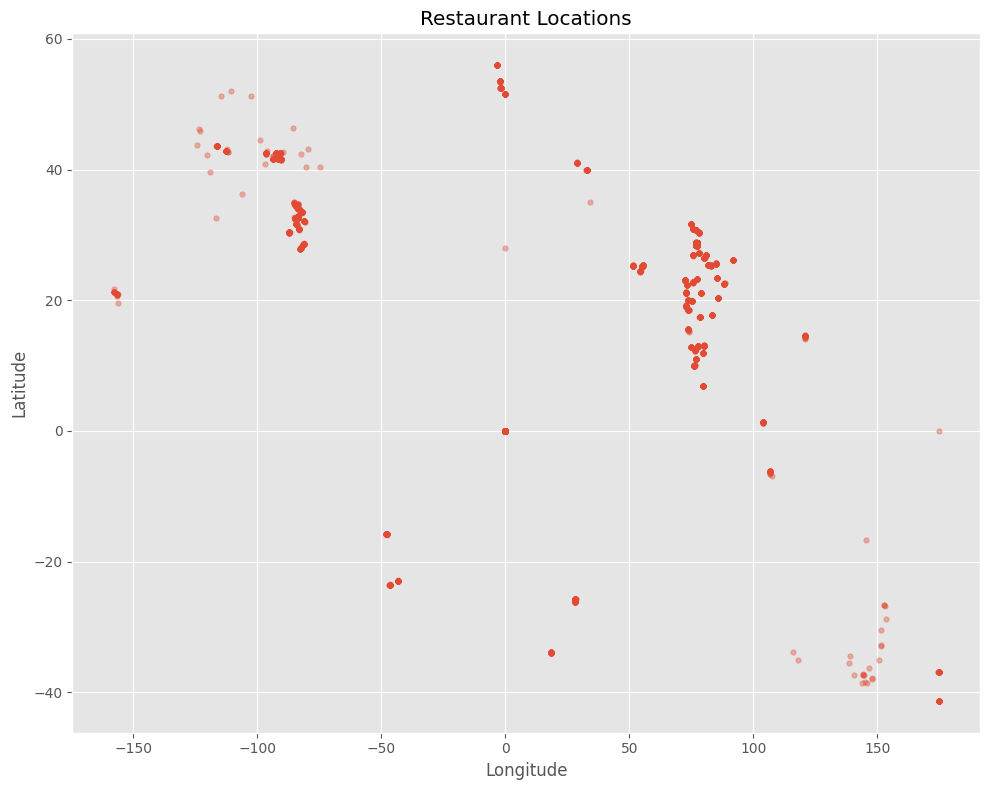

In [27]:
plt.figure(figsize=(10,8))

plt.scatter(
    geo_df["longitude"],
    geo_df["latitude"],
    alpha=0.4,
    s=15
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/restaurant_locations.png",
    dpi=300
)

plt.show()

In [30]:
import folium

In [31]:
restaurant_map = folium.Map(
    location=[
        geo_df["latitude"].mean(),
        geo_df["longitude"].mean()
    ],
    zoom_start=5
)

In [32]:
for _, row in geo_df.head(1000).iterrows():

    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=2,
        popup=row["restaurant_name"],
        color="blue",
        fill=True,
        fill_opacity=0.6
    ).add_to(restaurant_map)

In [33]:
restaurant_map.save(
    "../visuals/level2/restaurant_locations_map.html"
)

In [34]:
city_density = (
    geo_df.groupby("city")
    .size()
    .reset_index(name="Restaurant Count")
    .sort_values(
        by="Restaurant Count",
        ascending=False
    )
)

city_density.head(10)

,city,Restaurant Count
88,New Delhi,5473
50,Gurgaon,1118
89,Noida,1080
43,Faridabad,251
48,Ghaziabad,25
17,Bhubaneshwar,21
69,Lucknow,21
51,Guwahati,21
2,Ahmedabad,21
5,Amritsar,21


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\1987699529.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


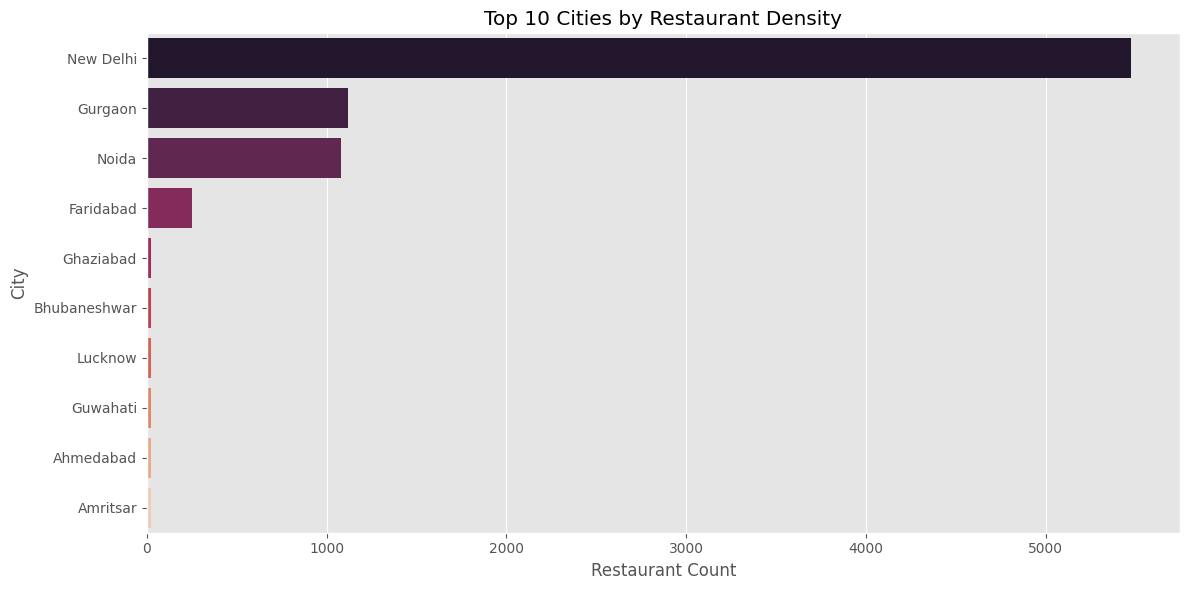

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=city_density.head(10),
    x="Restaurant Count",
    y="city",
    palette="rocket"
)

plt.title("Top 10 Cities by Restaurant Density")
plt.xlabel("Restaurant Count")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/city_restaurant_density.png",
    dpi=300
)

plt.show()

In [36]:
from sklearn.cluster import KMeans

In [37]:
coordinates = geo_df[["latitude", "longitude"]]

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init="auto"
)

geo_df["Cluster"] = kmeans.fit_predict(coordinates)

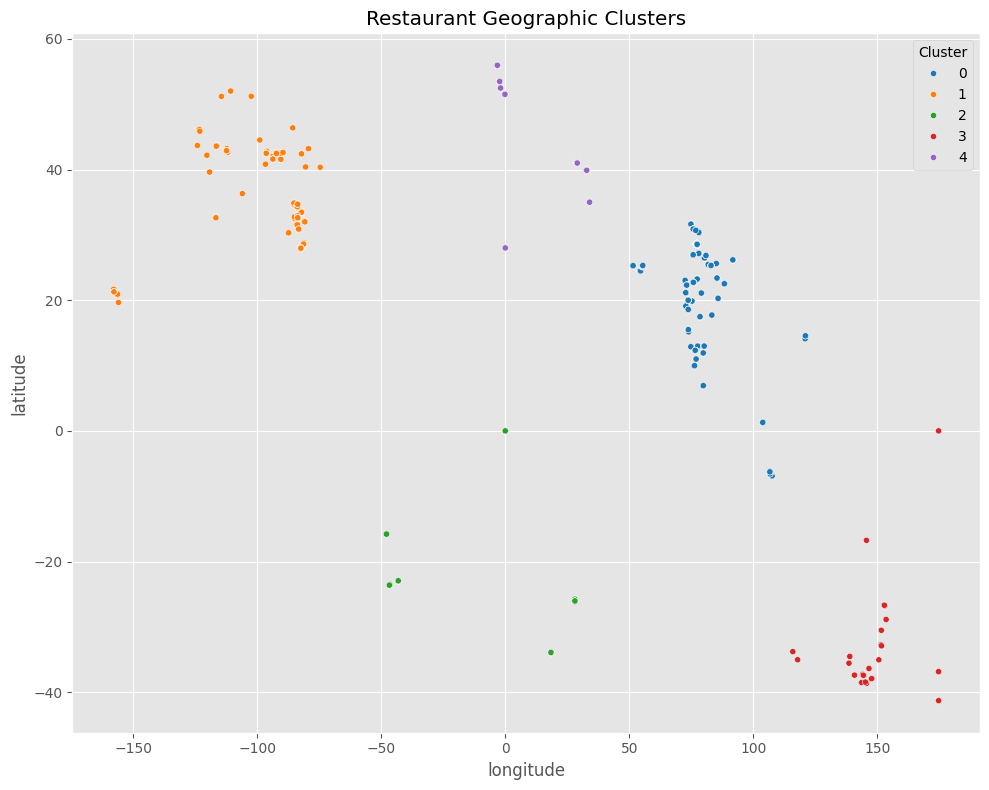

In [38]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=geo_df,
    x="longitude",
    y="latitude",
    hue="Cluster",
    palette="tab10",
    s=20
)

plt.title("Restaurant Geographic Clusters")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/geographic_clusters.png",
    dpi=300
)

plt.show()

In [39]:
city_density.to_csv(
    "../outputs/geographic_analysis.csv",
    index=False
)

In [40]:
city_density.head(10)

,city,Restaurant Count
88,New Delhi,5473
50,Gurgaon,1118
89,Noida,1080
43,Faridabad,251
48,Ghaziabad,25
17,Bhubaneshwar,21
69,Lucknow,21
51,Guwahati,21
2,Ahmedabad,21
5,Amritsar,21


## Key Insights

- Restaurants are concentrated in a few major cities, forming clear geographic clusters.
- The interactive map highlights areas with a high density of restaurants.
- K-Means clustering identifies groups of restaurants based on geographic proximity.
- Restaurant distribution is uneven, with urban regions containing significantly more restaurants than rural areas.

## Level 2 – Task 4: Restaurant Chains

## Objective

Identify restaurant chains present in the dataset and analyze their ratings and popularity.

In [41]:
chain_counts = (
    df["restaurant_name"]
    .value_counts()
    .reset_index()
)

chain_counts.columns = ["Restaurant Name", "Number of Outlets"]

chain_counts.head()

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48


In [42]:
restaurant_chains = chain_counts[
    chain_counts["Number of Outlets"] > 1
]

restaurant_chains.head()

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48


In [43]:
print("Total Restaurant Chains:", len(restaurant_chains))

Total Restaurant Chains: 734


In [44]:
top10_chains = restaurant_chains.head(10)

top10_chains

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [45]:
chain_analysis = (
    df.groupby("restaurant_name")
      .agg(
          Number_of_Outlets=("restaurant_name", "count"),
          Average_Rating=("aggregate_rating", "mean"),
          Average_Votes=("votes", "mean")
      )
      .reset_index()
)

chain_analysis = chain_analysis[
    chain_analysis["Number_of_Outlets"] > 1
]

chain_analysis["Average_Rating"] = chain_analysis["Average_Rating"].round(2)
chain_analysis["Average_Votes"] = chain_analysis["Average_Votes"].round(2)

chain_analysis.head()

,restaurant_name,Number_of_Outlets,Average_Rating,Average_Votes
7,10 Downing Street,2,4.00,335.00
27,221 B Baker Street,3,3.37,71.67
44,34 Parkstreet Lane,2,3.05,15.50
45,"34, Chowringhee Lane",12,2.79,64.75
59,4700BC Popcorn,2,3.50,88.00


In [46]:
top_rated_chains = (
    chain_analysis[
        chain_analysis["Number_of_Outlets"] >= 5
    ]
    .sort_values(
        by="Average_Rating",
        ascending=False
    )
)

top_rated_chains.head(10)

,restaurant_name,Number_of_Outlets,Average_Rating,Average_Votes
1510,Chili's,5,4.58,1631.20
2297,Farzi Cafe,6,4.37,1683.00
663,Barbeque Nation,26,4.35,1082.38
5060,Punjab Grill,5,4.34,1084.80
4214,Mocha,7,4.19,444.43
6374,Texas Roadhouse,5,3.86,156.60
2849,Happy Hakka,5,3.86,294.20
6232,TGI Friday's,6,3.85,726.17
3640,L'Opera,5,3.82,209.20
6080,Starbucks,18,3.81,396.61


In [47]:
most_popular = (
    chain_analysis[
        chain_analysis["Number_of_Outlets"] >= 5
    ]
    .sort_values(
        by="Average_Votes",
        ascending=False
    )
)

most_popular.head(10)

,restaurant_name,Number_of_Outlets,Average_Rating,Average_Votes
2297,Farzi Cafe,6,4.37,1683.00
1510,Chili's,5,4.58,1631.20
5060,Punjab Grill,5,4.34,1084.80
663,Barbeque Nation,26,4.35,1082.38
4446,Nando's,5,3.14,809.00
6232,TGI Friday's,6,3.85,726.17
3488,Khan Chacha,7,2.47,658.57
728,Berco's,9,3.17,599.33
3405,Karim's,13,3.03,529.08
3351,Kake Da Hotel,5,3.28,465.40


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\2137938037.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


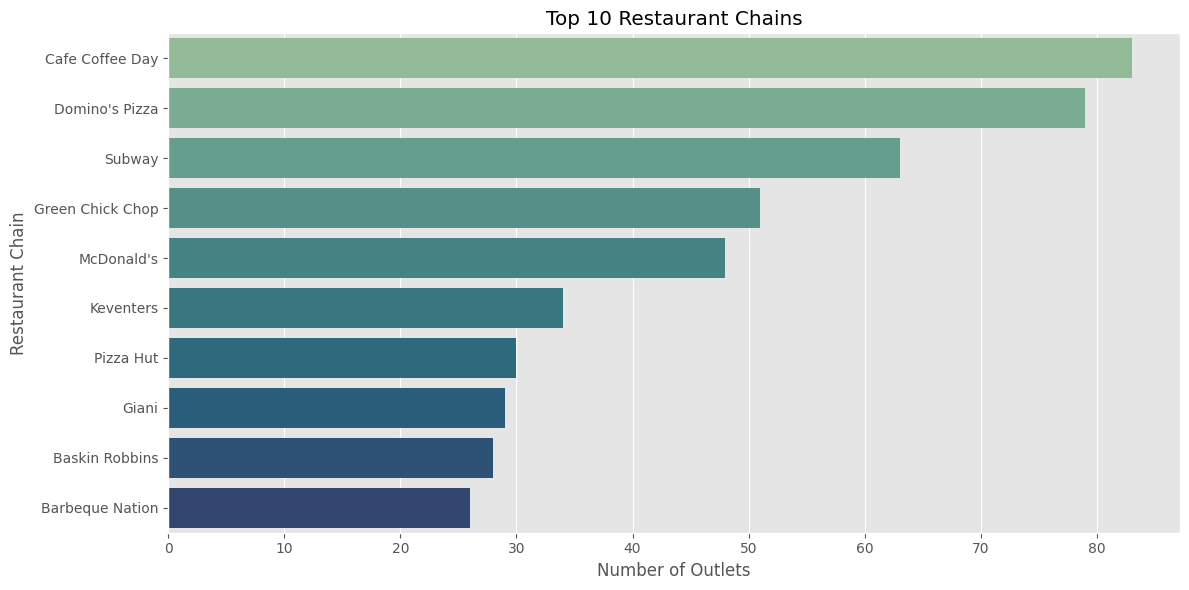

In [48]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_chains,
    x="Number of Outlets",
    y="Restaurant Name",
    palette="crest"
)

plt.title("Top 10 Restaurant Chains")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/top_restaurant_chains.png",
    dpi=300
)

plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\2330653006.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


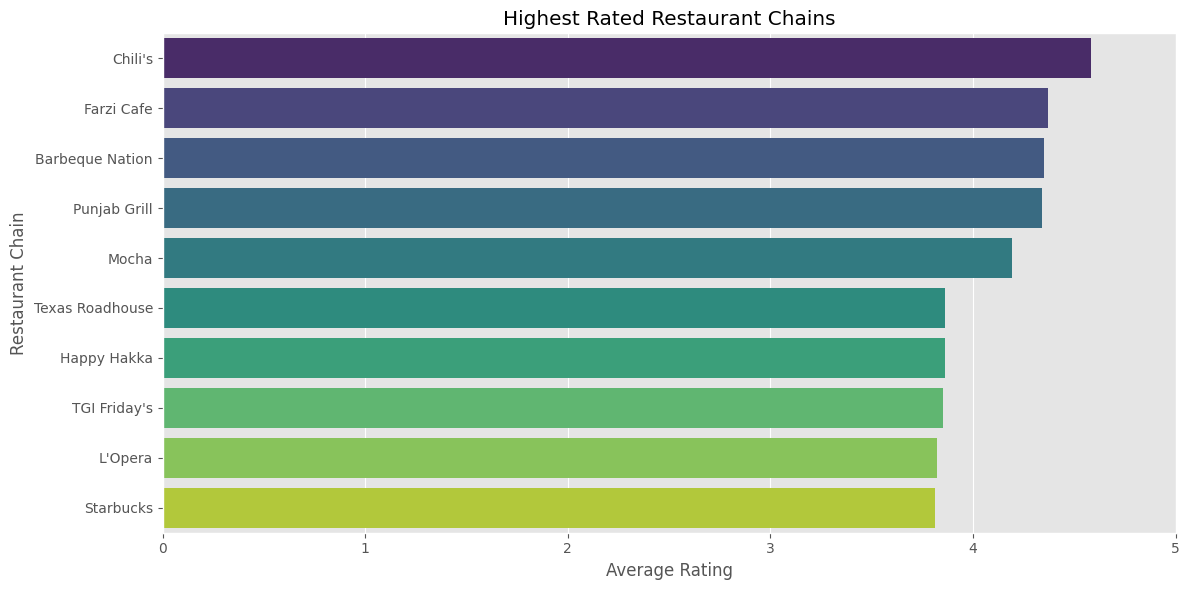

In [49]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated_chains.head(10),
    x="Average_Rating",
    y="restaurant_name",
    palette="viridis"
)

plt.title("Highest Rated Restaurant Chains")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Chain")

plt.xlim(0,5)

plt.tight_layout()

plt.savefig(
    "../visuals/level2/highest_rated_chains.png",
    dpi=300
)

plt.show()

C:\Users\Abhinav\AppData\Local\Temp\ipykernel_3456\2258499116.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


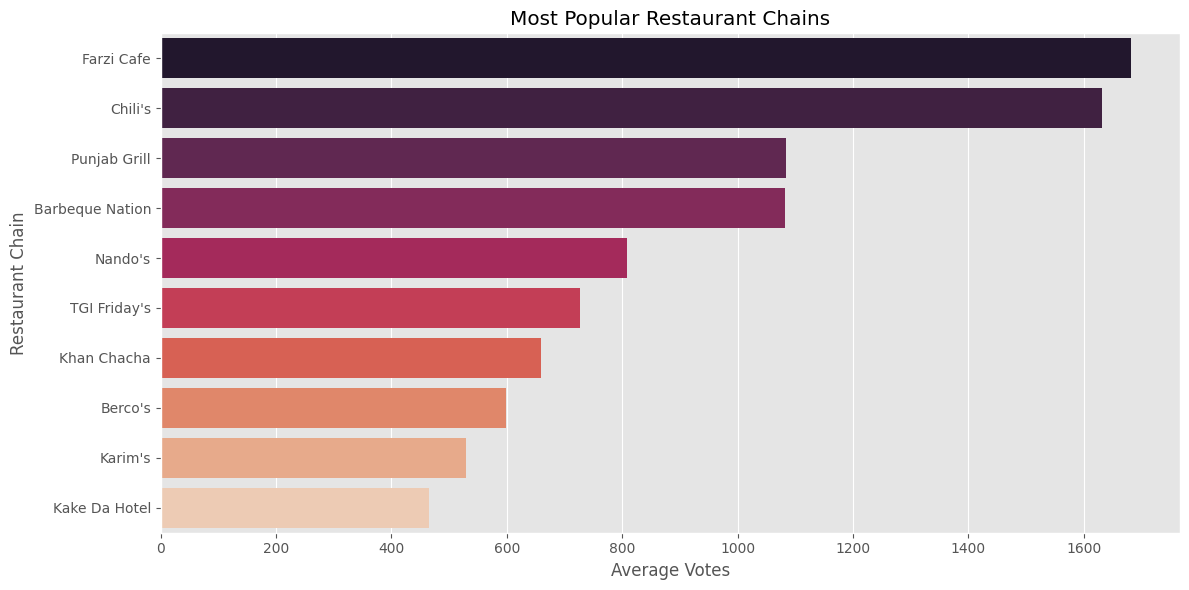

In [50]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=most_popular.head(10),
    x="Average_Votes",
    y="restaurant_name",
    palette="rocket"
)

plt.title("Most Popular Restaurant Chains")
plt.xlabel("Average Votes")
plt.ylabel("Restaurant Chain")

plt.tight_layout()

plt.savefig(
    "../visuals/level2/most_popular_chains.png",
    dpi=300
)

plt.show()

In [51]:
chain_analysis.to_csv(
    "../outputs/restaurant_chain_analysis.csv",
    index=False
)

In [52]:
top10_chains

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [53]:
top_rated_chains.head(10)

,restaurant_name,Number_of_Outlets,Average_Rating,Average_Votes
1510,Chili's,5,4.58,1631.20
2297,Farzi Cafe,6,4.37,1683.00
663,Barbeque Nation,26,4.35,1082.38
5060,Punjab Grill,5,4.34,1084.80
4214,Mocha,7,4.19,444.43
6374,Texas Roadhouse,5,3.86,156.60
2849,Happy Hakka,5,3.86,294.20
6232,TGI Friday's,6,3.85,726.17
3640,L'Opera,5,3.82,209.20
6080,Starbucks,18,3.81,396.61


In [54]:
most_popular.head(10)

,restaurant_name,Number_of_Outlets,Average_Rating,Average_Votes
2297,Farzi Cafe,6,4.37,1683.00
1510,Chili's,5,4.58,1631.20
5060,Punjab Grill,5,4.34,1084.80
663,Barbeque Nation,26,4.35,1082.38
4446,Nando's,5,3.14,809.00
6232,TGI Friday's,6,3.85,726.17
3488,Khan Chacha,7,2.47,658.57
728,Berco's,9,3.17,599.33
3405,Karim's,13,3.03,529.08
3351,Kake Da Hotel,5,3.28,465.40


## Key Insights

- Several restaurant brands operate multiple outlets, indicating the presence of established restaurant chains.
- Chains with a larger number of outlets do not necessarily have the highest average ratings.
- Some chains consistently achieve both high customer ratings and strong customer engagement (measured by average votes).
- Customer popularity and customer satisfaction are related but do not always align across restaurant chains.